# Differentially Private Synthetic Data Generation — Experimental Study

This notebook demonstrates a marginal-based DP synthetic data pipeline and evaluates its utility via classification performance across multiple datasets and privacy budgets (ε).

**Structure:**
1. Setup & data loading
2. Single-run: generate synthetic data and compare with original
3. Epsilon-sweep study across multiple datasets
4. Results summary & pivot tables
5. Visualization (accuracy, distributions, epsilon curves)
6. PrivBayes baseline comparison

## 1. Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dp_synth import (
    generate, evaluate_df,
    run_epsilon_study, summarize_study,
    privbayes_synthesize, run_privbayes_study,
    apply_plot_defaults, savefig,
    plot_accuracy_bar, plot_accuracy_box, plot_confusion_matrix,
    plot_feature_distribution, plot_multi_feature_distributions,
    plot_epsilon_curves, plot_epsilon_diff, plot_epsilon_std,
    plot_synth_vs_privbayes, plot_three_way_bar,
)

apply_plot_defaults()

### Load datasets

The datasets use pre-discretized columns (suffix ). All columns are treated as categorical; the last column is the class variable.

In [6]:
adult = pd.read_csv("data/adult_mrf.csv")
acs   = pd.read_csv("data/acs_mrf.csv")
br2000 = pd.read_csv("data/br2000_mrf.csv")

print(f"adult:  {adult.shape}")
print(f"acs:    {acs.shape}")
print(f"br2000: {br2000.shape}")

adult.head()

adult:  (45222, 15)
acs:    (47461, 23)
br2000: (38000, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,4,State-gov,0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,6,United-States,<=50K
1,7,Self-emp-not-inc,0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,1,United-States,<=50K
2,4,Private,1,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,6,United-States,<=50K
3,7,Private,2,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,6,United-States,<=50K
4,2,Private,3,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,6,Cuba,<=50K


## 2. Single run: Original vs Synthetic (ε = 1.0)

Generate one synthetic dataset from the Adult data with the default privacy budget, then evaluate classification accuracy on both.

In [7]:
synthetic_data = generate(adult, epsilon=1.0)
synthetic_data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,3,Private,0,HS-grad,10,Never-married,Craft-repair,Husband,White,Male,0,0,6,United-States,<=50K
1,0,Private,3,HS-grad,13,Divorced,Machine-op-inspct,Not-in-family,White,Female,0,0,3,United-States,<=50K
2,9,Private,2,Bachelors,14,Never-married,Sales,Husband,Asian-Pac-Islander,Male,0,6,6,United-States,>50K
3,5,Local-gov,5,Bachelors,11,Divorced,Sales,Husband,White,Female,0,0,10,United-States,>50K
4,3,Private,1,Some-college,10,Married-AF-spouse,Craft-repair,Not-in-family,White,Male,0,0,2,Jamaica,<=50K


In [8]:
synth_results = evaluate_df(synthetic_data, adult, n_splits=10)
orig_results  = evaluate_df(adult, n_splits=10)

print("Original:")
print(f"  Accuracy:  {orig_results['accuracies'].mean():.4f} ± {orig_results['accuracies'].std():.4f}")

print("Synthetic (ε = 1.0):")
print(f"  Accuracy:  {synth_results['accuracies'].mean():.4f} ± {synth_results['accuracies'].std():.4f}")

Original:
  Accuracy:  0.9565 ± 0.0000
Synthetic (ε = 1.0):
  Accuracy:  0.8153 ± 0.0008


## 3. Epsilon-sweep study

For each dataset and each ε value, generate synthetic data 10 times and measure classification performance.

> **Note:** This cell takes a long time to run (hours, depending on hardware). Consider reducing  or the epsilon list for a quick test.

In [9]:
datasets = {
    "acs": acs,
    "adult": adult,
    "br2000": br2000,
}

epsilons = [0.01, 0.02, 0.05, 0.08, 0.1, 0.2, 0.4, 0.8, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

study_results = run_epsilon_study(datasets, epsilons, n_reps=10, n_splits=10)

  Dataset: acs
  Dataset: adult
  Dataset: br2000


## 4. Results summary

In [10]:
summary = summarize_study(study_results)

print("=== Summary per dataset & epsilon ===")
summary

=== Summary per dataset & epsilon ===


,dataset,epsilon,mean_acc_synth,std_acc_synth,mean_acc_orig,std_acc_orig,n_runs,diff_mean
0,acs,0.01,0.886078,0.066740,0.944411,0.0,10,-0.058334
1,acs,0.02,0.922494,0.006670,0.944411,0.0,10,-0.021917
2,acs,0.05,0.923651,0.005514,0.944411,0.0,10,-0.020760
3,acs,0.08,0.919183,0.007919,0.944411,0.0,10,-0.025228
4,acs,0.10,0.924460,0.005880,0.944411,0.0,10,-0.019951
5,acs,0.20,0.923030,0.002408,0.944411,0.0,10,-0.021381
6,acs,0.40,0.924376,0.003211,0.944411,0.0,10,-0.020035
7,acs,0.80,0.924115,0.002299,0.944411,0.0,10,-0.020296
8,acs,1.00,0.922255,0.005471,0.944411,0.0,10,-0.022156
9,acs,2.00,0.923438,0.002430,0.944411,0.0,10,-0.020973


In [12]:
pivot_synth = summary.pivot(index="epsilon", columns="dataset", values="mean_acc_synth")
pivot_diff  = summary.pivot(index="epsilon", columns="dataset", values="diff_mean")

print("Synthetic accuracy (rows: epsilon, columns: datasets)")
print(pivot_synth)

print("Difference (synthetic − original)")
print(pivot_diff)

Synthetic accuracy (rows: epsilon, columns: datasets)
dataset       acs     adult    br2000
epsilon                              
0.01     0.886078  0.786785  0.736515
0.02     0.922494  0.804358  0.731205
0.05     0.923651  0.819880  0.793711
0.08     0.919183  0.822812  0.797999
0.10     0.924460  0.822314  0.799089
0.20     0.923030  0.820316  0.799748
0.40     0.924376  0.818235  0.799772
0.80     0.924115  0.819368  0.801557
1.00     0.922255  0.817890  0.800685
2.00     0.923438  0.818259  0.800533
4.00     0.923803  0.818654  0.800244
8.00     0.922745  0.818758  0.799810
16.00    0.924195  0.817177  0.801157
32.00    0.923386  0.819538  0.800359
Difference (synthetic − original)
dataset       acs     adult    br2000
epsilon                              
0.01    -0.058334 -0.169717 -0.215748
0.02    -0.021917 -0.152143 -0.221058
0.05    -0.020760 -0.136621 -0.158553
0.08    -0.025228 -0.133689 -0.154264
0.10    -0.019951 -0.134188 -0.153174
0.20    -0.021381 -0.136185 -0.152515


## 5. Visualization

### 5.1 Single-run accuracy comparison

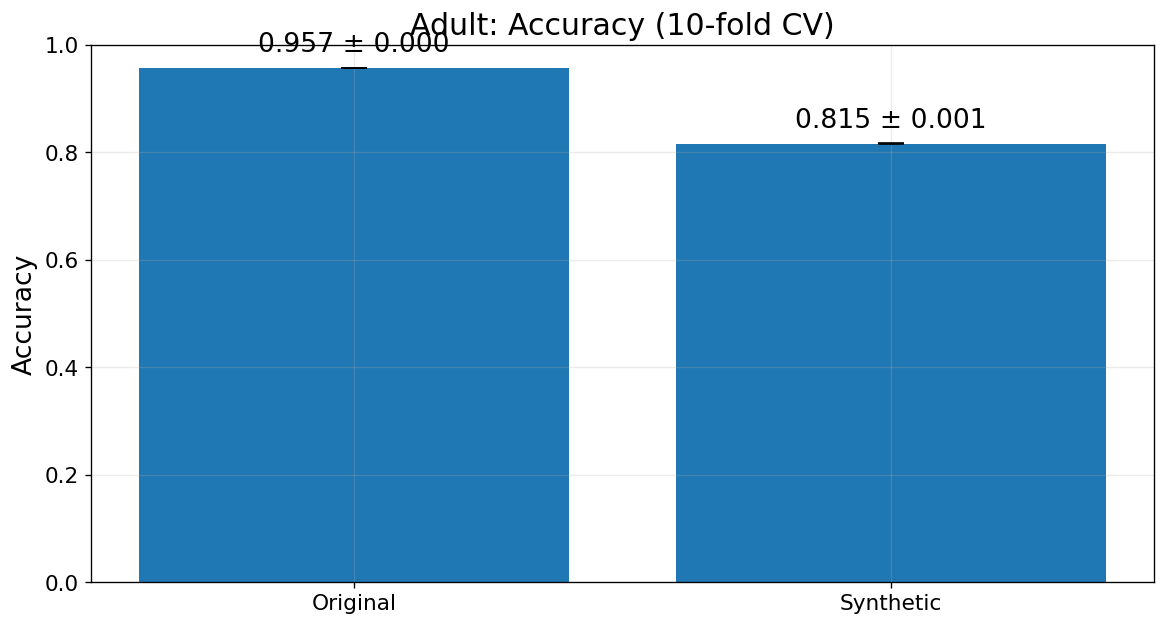

In [13]:
plot_accuracy_bar(orig_results, synth_results, title="Adult: Accuracy (10-fold CV)")
savefig("acc_bar_original_vs_synth")

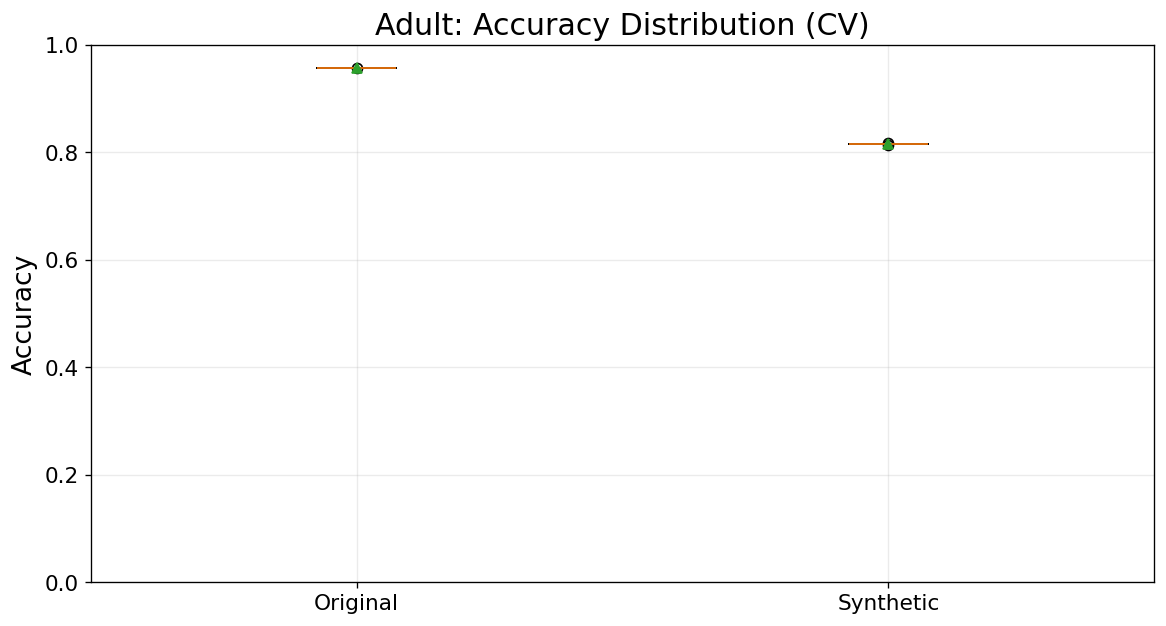

In [14]:
plot_accuracy_box(orig_results, synth_results, title="Adult: Accuracy Distribution (CV)")
savefig("acc_box_original_vs_synth")

### 5.2 Confusion matrices

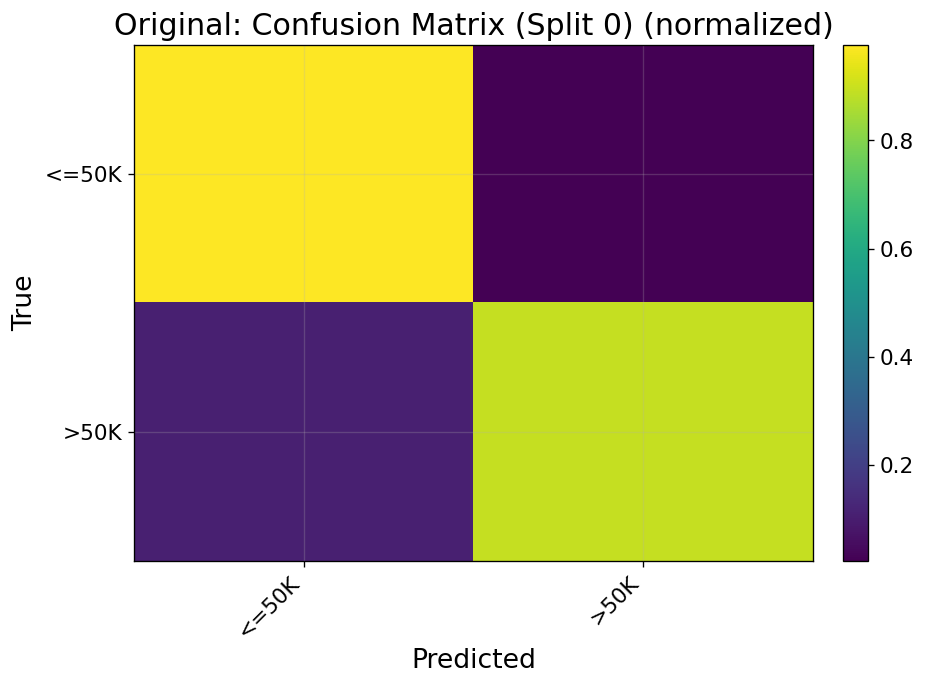

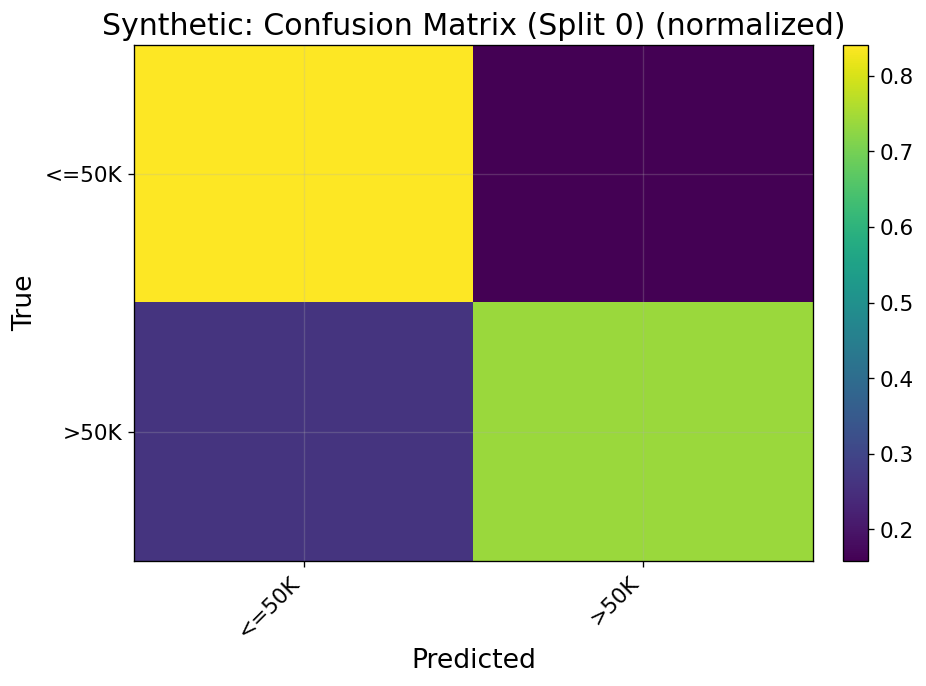

In [15]:
plot_confusion_matrix(
    orig_results["confusion_matrices"][0],
    orig_results["classes"],
    title="Original: Confusion Matrix (Split 0)",
)
savefig("cm_original_split0")

plot_confusion_matrix(
    synth_results["confusion_matrices"][0],
    synth_results["classes"],
    title="Synthetic: Confusion Matrix (Split 0)",
)
savefig("cm_synth_split0")

### 5.3 Feature distributions (Original vs Synthetic)

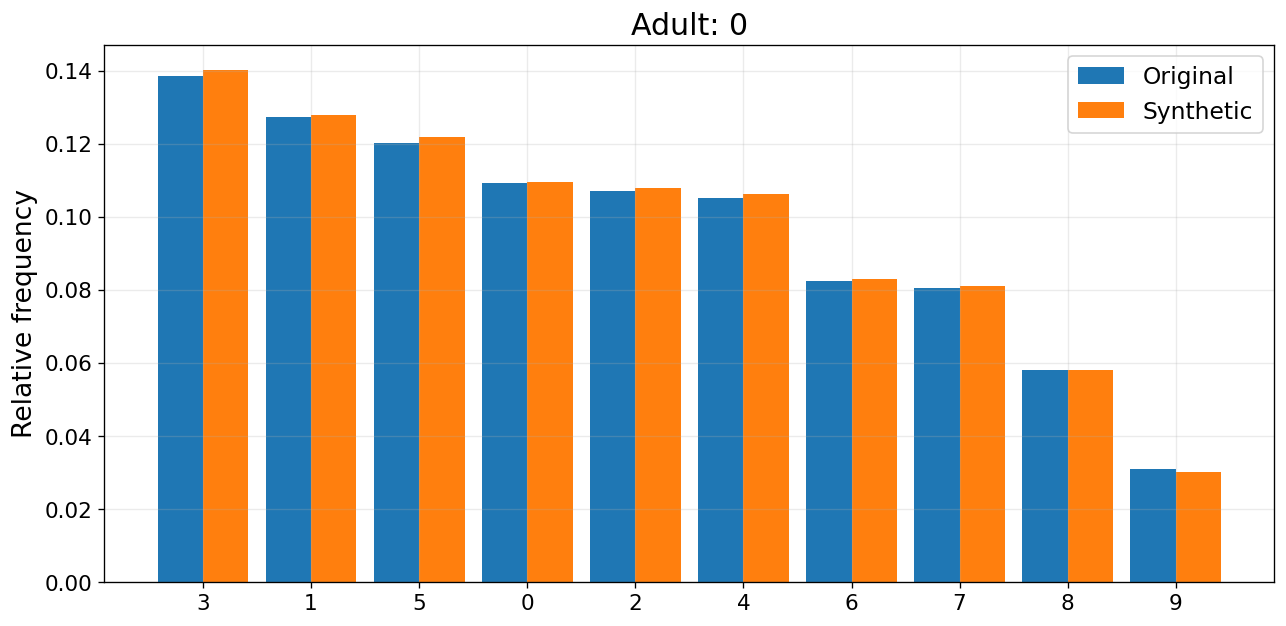

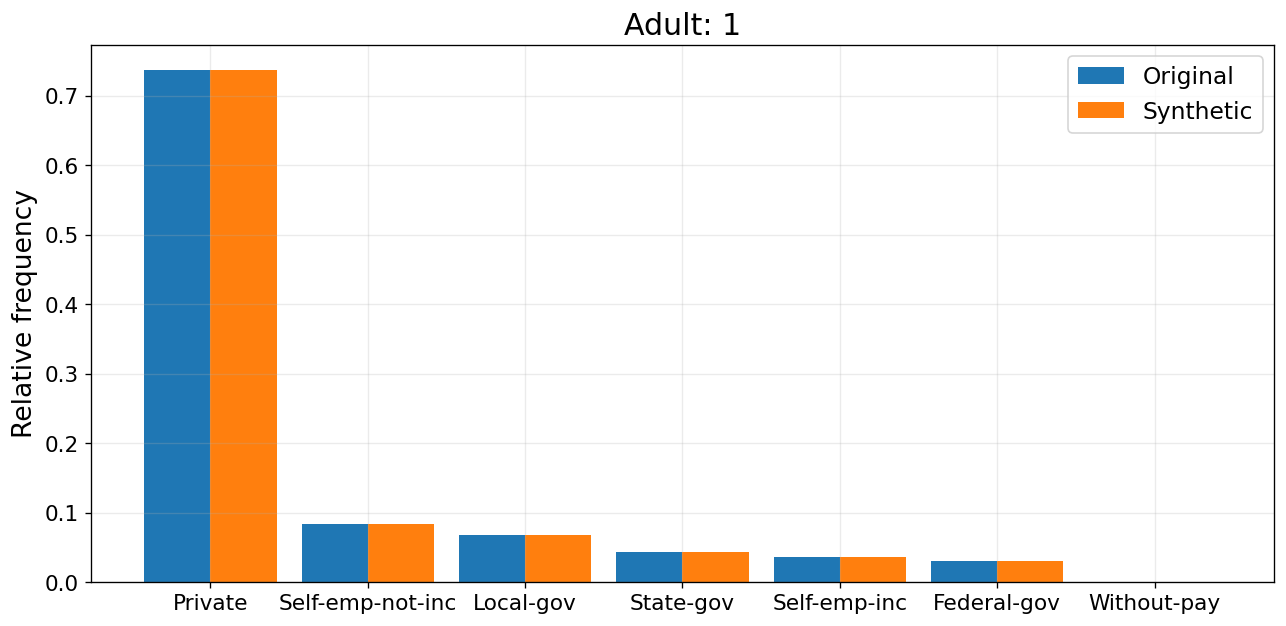

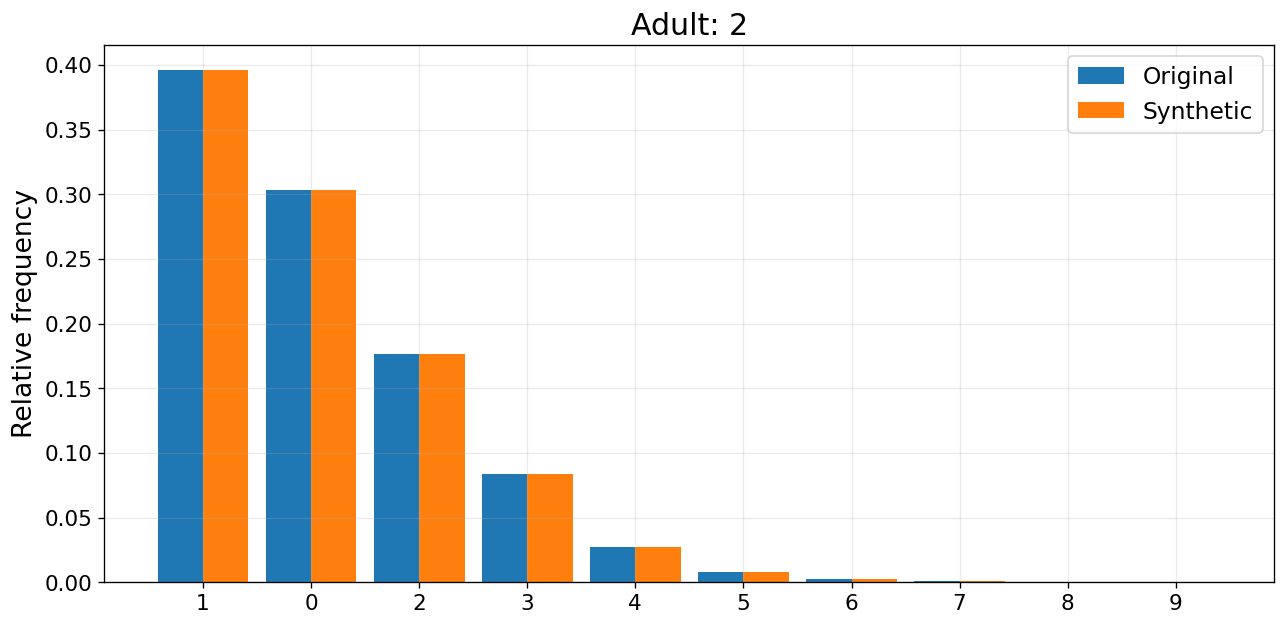

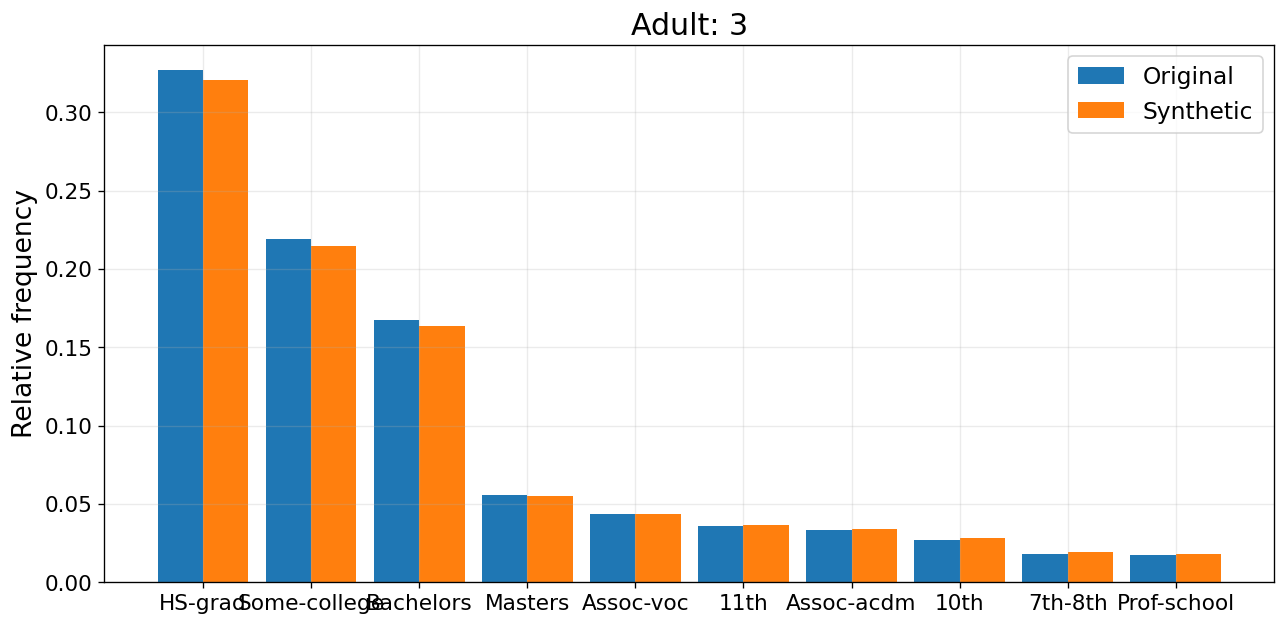

In [16]:
feature_cols = adult.columns[:-1]

for col in feature_cols[:4]:
    plot_feature_distribution(col, adult, synthetic_data, top_k=10, title=f"Adult: {col}")
    savefig(f"dist_{col}")

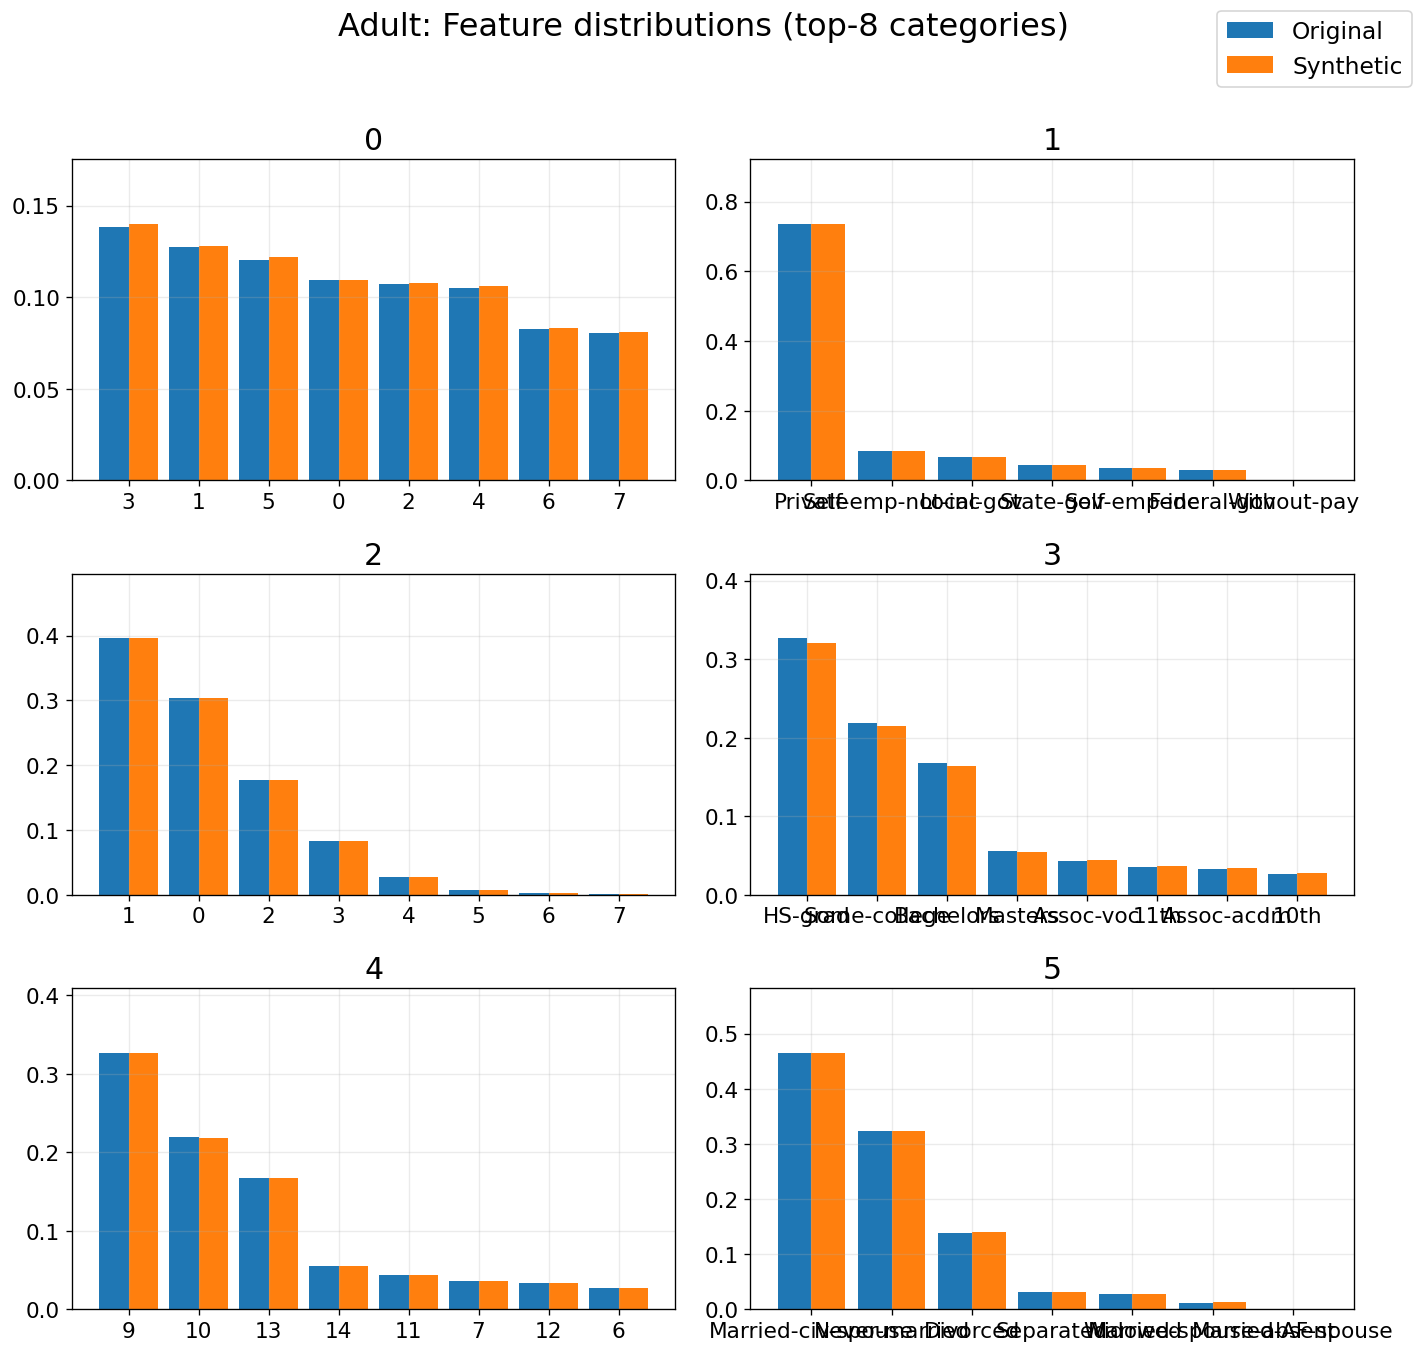

In [17]:
cols = list(feature_cols[:6])
plot_multi_feature_distributions(
    cols, adult, synthetic_data,
    top_k=8, ncols=2,
    suptitle="Adult: Feature distributions (top-8 categories)",
)
savefig("dist_multi_6features")

### 5.4 Epsilon curves

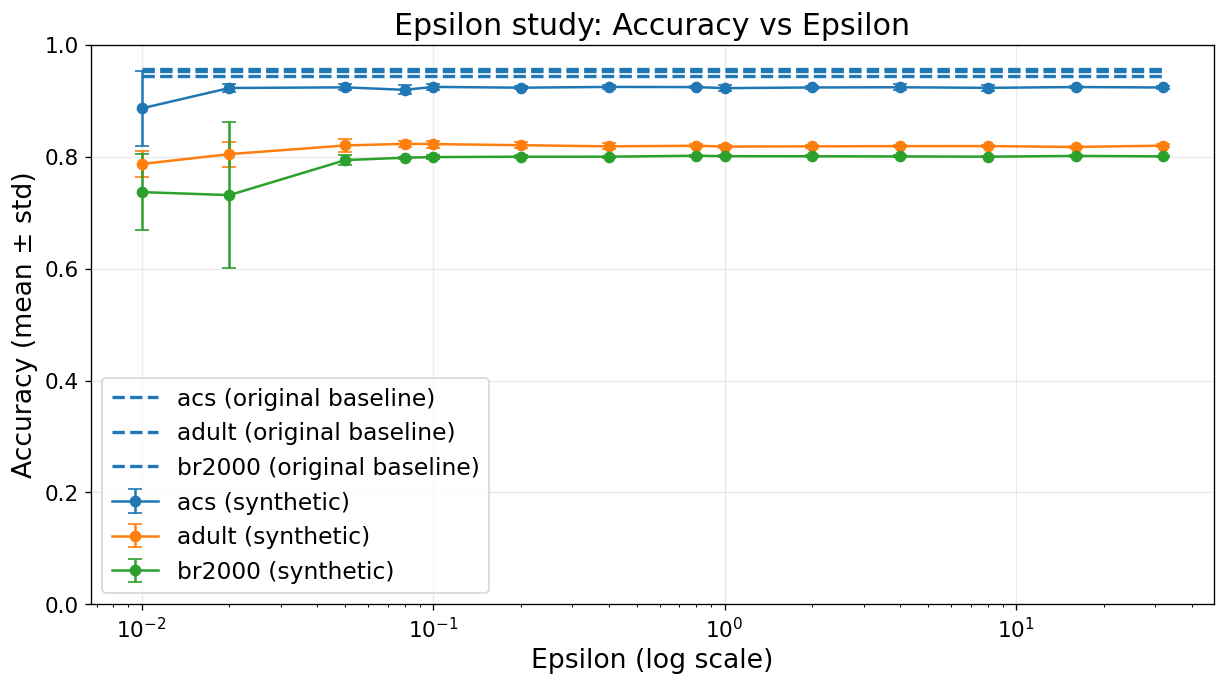

In [18]:
plot_epsilon_curves(summary, title="Epsilon study: Accuracy vs Epsilon")
savefig("epsilon_curves_accuracy")

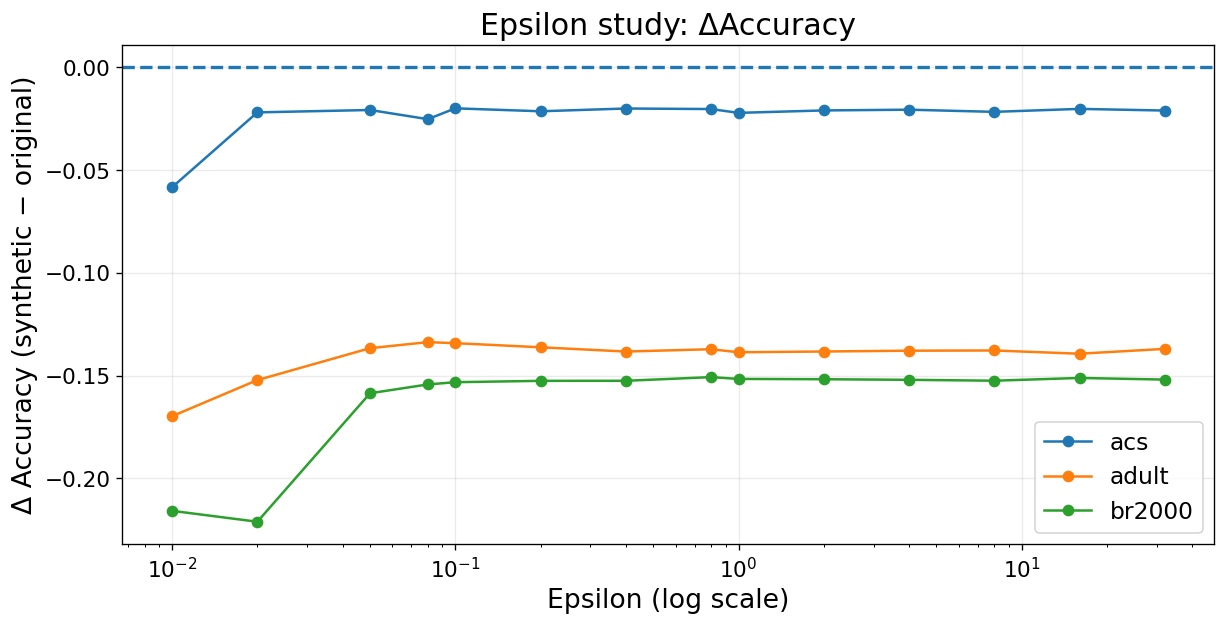

In [19]:
plot_epsilon_diff(summary, title="Epsilon study: ΔAccuracy")
savefig("epsilon_diff_accuracy")

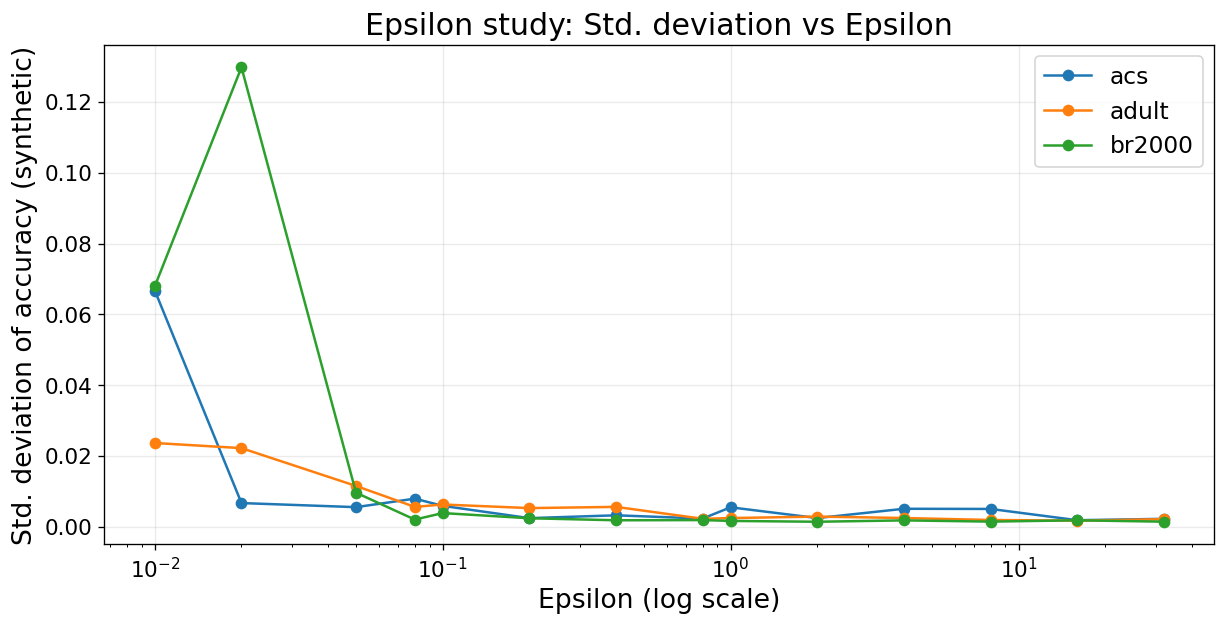

In [20]:
plot_epsilon_std(summary, title="Epsilon study: Std. deviation vs Epsilon")
savefig("epsilon_std_accuracy")

## 6. PrivBayes baseline comparison

> **Requires:** 
>
> This section compares the marginal-based approach with PrivBayes (correlated-attribute mode from the DataSynthesizer library).

### 6.1 Single-run comparison (ε = 0.5)

================ Constructing Bayesian Network (BN) ================
Adding ROOT 13
Adding attribute 8
Adding attribute 7
Adding attribute 5
Adding attribute 9
Adding attribute 0
Adding attribute 14
Adding attribute 6
Adding attribute 4
Adding attribute 3
Adding attribute 10
Adding attribute 12
Adding attribute 1
Adding attribute 11
Adding attribute 2
========================== BN constructed ==========================


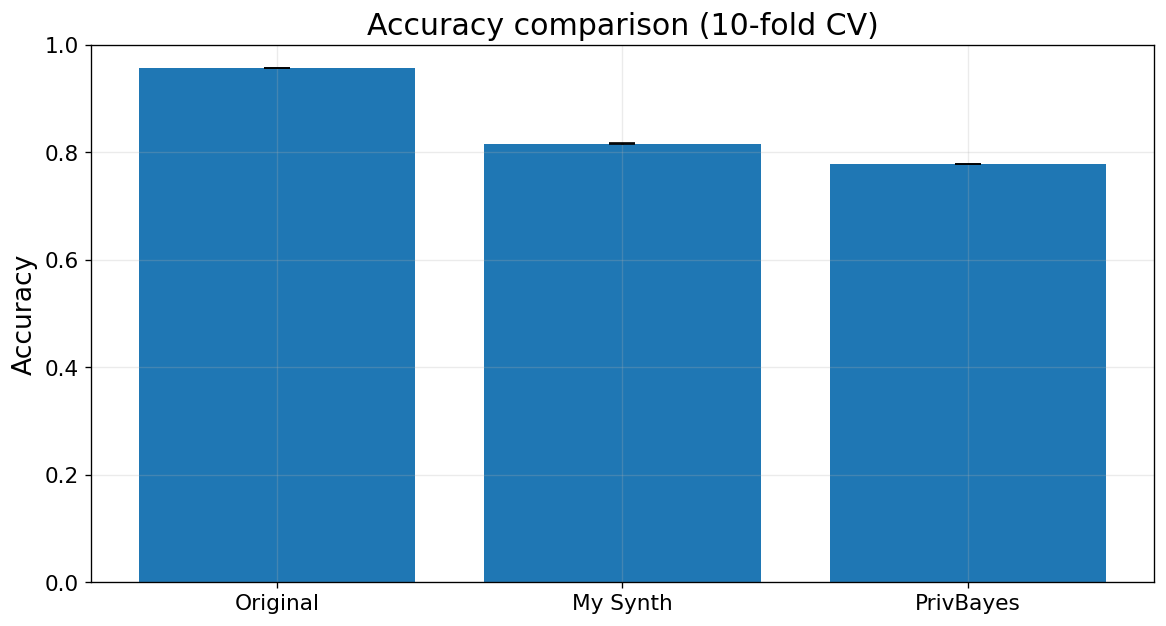

In [21]:
priv_synth = privbayes_synthesize(adult, epsilon=0.5, dataset_name="adult")
priv_results = evaluate_df(priv_synth, adult, n_splits=10)

plot_three_way_bar(
    orig_results, synth_results, priv_results,
    title="Accuracy comparison (10-fold CV)",
)
savefig("three_way_bar")

### 6.2 PrivBayes epsilon sweep

In [22]:
pb_summary = run_privbayes_study(adult, epsilons, n_splits=10, dataset_name="adult")
pb_summary

================ Constructing Bayesian Network (BN) ================
Adding ROOT 13
Adding attribute 7
Adding attribute 10
Adding attribute 8
Adding attribute 5
Adding attribute 4
Adding attribute 9
Adding attribute 3
Adding attribute 14
Adding attribute 12
Adding attribute 1
Adding attribute 11
Adding attribute 2
Adding attribute 6
Adding attribute 0
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT 13
Adding attribute 7
Adding attribute 10
Adding attribute 8
Adding attribute 5
Adding attribute 4
Adding attribute 9
Adding attribute 3
Adding attribute 14
Adding attribute 12
Adding attribute 1
Adding attribute 11
Adding attribute 2
Adding attribute 6
Adding attribute 0
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT 13
Adding attribute 7
Adding attribute 9
Adding attribute 6
Adding attrib

c:\Users\rober\AppData\Local\Programs\Python\Python313\Lib\site-packages\DataSynthesizer\lib\PrivBayes.py:193: RuntimeWarning: overflow encountered in exp
  mi_array = np.exp(mi_array)


Adding attribute 3
Adding attribute 6
Adding attribute 9
Adding attribute 7
Adding attribute 5
Adding attribute 14
Adding attribute 0
Adding attribute 12
Adding attribute 1
Adding attribute 10
Adding attribute 2
Adding attribute 11
========================== BN constructed ==========================
================ Constructing Bayesian Network (BN) ================
Adding ROOT 13
Adding attribute 8
Adding attribute 4


c:\Users\rober\AppData\Local\Programs\Python\Python313\Lib\site-packages\DataSynthesizer\lib\PrivBayes.py:193: RuntimeWarning: overflow encountered in exp
  mi_array = np.exp(mi_array)


Adding attribute 3
Adding attribute 6
Adding attribute 9
Adding attribute 7
Adding attribute 5
Adding attribute 14
Adding attribute 0
Adding attribute 12
Adding attribute 1
Adding attribute 10
Adding attribute 2
Adding attribute 11
========================== BN constructed ==========================


,epsilon,privbayes_mean_acc,privbayes_std_acc
0,0.01,0.651716,0.004916
1,0.02,0.730958,0.002501
2,0.05,0.671949,0.002790
3,0.08,0.726688,0.001796
4,0.10,0.743751,0.000777
5,0.20,0.777111,0.000731
6,0.40,0.768478,0.000735
7,0.80,0.756006,0.000815
8,1.00,0.803189,0.000743
9,2.00,0.814995,0.000548


### 6.3 Combined epsilon curve: Marginal-based vs PrivBayes

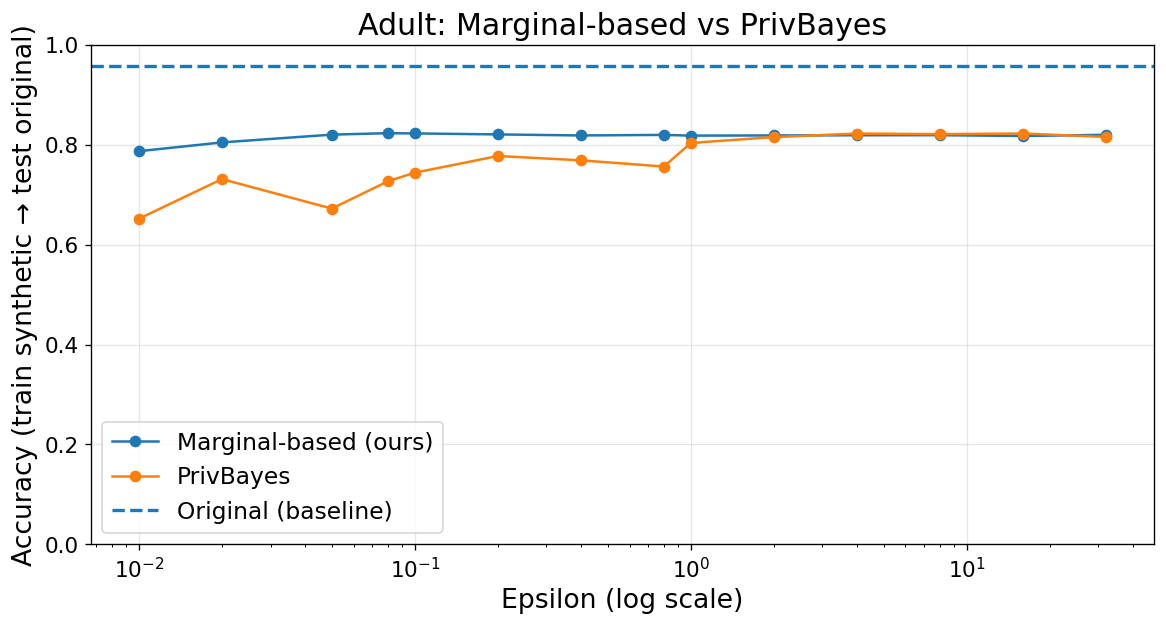

In [23]:
plot_synth_vs_privbayes(
    summary, pb_summary,
    dataset="adult",
    title="Adult: Marginal-based vs PrivBayes",
)
savefig("synth_vs_privbayes")